---
<div style='background-color:honeydew; font-size: 24px;'>
    <center><strong>Segmentation Node Documentation</strong></center>
</div>

---

This Jupyter Notebook will walk you through the first step in iris recognition, `segmentation`, and does this through the `iris.nodes.segmentation` node. From it you will learn how to:
- Load and prepare an infrared (IR) eye image for processing  
- Run the multilabel iris segmentation model  
- Interpret the model’s pixel-wise class probability outputs  
- Convert probabilities into a segmentation map  
- Visualize the segmented iris regions  
- Generate geometry and noise masks for downstream pipeline steps

---
<div style='background-color:honeydew; font-size: 24px;'>
    <center><strong>MultilabelSegmentation</strong></center>
</div>

---

Example from pipeline.yaml:

<code> - <font color='green'>name: segmentation</font>
    algorithm:    
      class_name: <font color='blue'>iris.MultilabelSegmentation.create_from_hugging_face</font>
      params: {}
          denoise: True</code>      
<code>    inputs:
      - name: image
        source_node: input
    callbacks:</code>

### What it does

The MultilabelSegmentation class creates a segmentation model of an image by predicting the probability each pixel falls into one of these classes:

**CLASSES_MAPPING = { 0: "eyeball", 1: "iris", 2: "pupil", 3: "eyelashes", }**

The instance uses the `ONNXMultilabelSegmentation` function and pretrained model from the repository hosted on Hugging Face. The model is stored locally and prepared for inference using ONNX Runtime.

**Key parameters**


| Parameter | Input Type | Default Value | What it controls |
|---|---|---| --- |
| `model_path` | `'str'` |  | Path to the ONNX model.
| `input_resolution` | `Tuple[PositiveInt, PositiveInt]` | (640, 480) | Neural Network input image resolution. |
| `input_num_channels` | `Literal[1, 3]` | 3 | Neural Network input image number of channels. |
| `denoise` | `bool` | False | Whether to apply denoising preprocessing step. |
| `callbacks` | `List[Callback]` | [ ] | List of algorithm callbacks. |

**Code \& Visualization Cells**

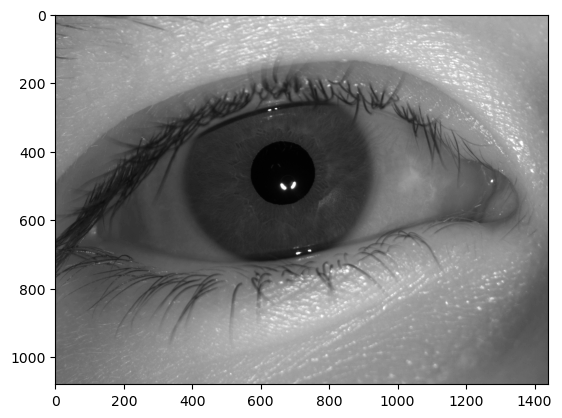

In [53]:
# ---- Imports ----
import cv2
import matplotlib.pyplot as plt
import iris
from iris.io.dataclasses import IRImage
from iris.nodes.segmentation.onnx_multilabel_segmentation import ONNXMultilabelSegmentation

# ---- Load image ----

img_pixels = cv2.imread("./sample_ir_image.png", cv2.IMREAD_GRAYSCALE)
plt.imshow(img_pixels, cmap = 'gray')

In [63]:
# ---- Create an IRImage object from sample image ----
ir_img = IRImage(
    img_data = img_pixels,
    width = img_pixels.shape[1],
    height = img_pixels.shape[0],
    eye_side = 'right'
)

# ---- ONNXMultilabelSegmentation Model ----
segmenter = ONNXMultilabelSegmentation.create_from_hugging_face()
segmentation_result = segmenter.run(ir_img)

print(segmentation_result.predictions)
print('Dimensions of Segmentation map:', segmentation_result.predictions.shape)

[[[0.0000000e+00 6.8545341e-07 3.5762787e-07 5.3942204e-06]
  [0.0000000e+00 6.8545341e-07 3.5762787e-07 5.3942204e-06]
  [0.0000000e+00 6.8545341e-07 3.5762787e-07 5.3942204e-06]
  ...
  [0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00]
  [7.1525574e-07 2.0861626e-07 0.0000000e+00 9.1493130e-06]
  [7.1525574e-07 2.0861626e-07 0.0000000e+00 9.1493130e-06]]

 [[0.0000000e+00 6.8545341e-07 3.5762787e-07 5.3942204e-06]
  [0.0000000e+00 6.8545341e-07 3.5762787e-07 5.3942204e-06]
  [0.0000000e+00 6.8545341e-07 3.5762787e-07 5.3942204e-06]
  ...
  [0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00]
  [7.1525574e-07 2.0861626e-07 0.0000000e+00 9.1493130e-06]
  [7.1525574e-07 2.0861626e-07 0.0000000e+00 9.1493130e-06]]

 [[0.0000000e+00 6.8545341e-07 3.5762787e-07 5.3942204e-06]
  [0.0000000e+00 6.8545341e-07 3.5762787e-07 5.3942204e-06]
  [0.0000000e+00 6.8545341e-07 3.5762787e-07 5.3942204e-06]
  ...
  [0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00]
  [7.1525574e-07 2

### What to look for

The form of each each pixel will look like:

**[prob_eyeball, prob_iris, prob_pupil, prob_eyelashes]**

For example: [0.0000000e+00, 6.8545341e-07, 3.5762787e-07, 5.3942204e-06]
- The highest value here is 5.3942204e-06, so predicted class is eyelash

`.predictions.shape()` returns the dimensions of the segmentation map in the form of:

    (Height, Width, Number of Classes Predicted)

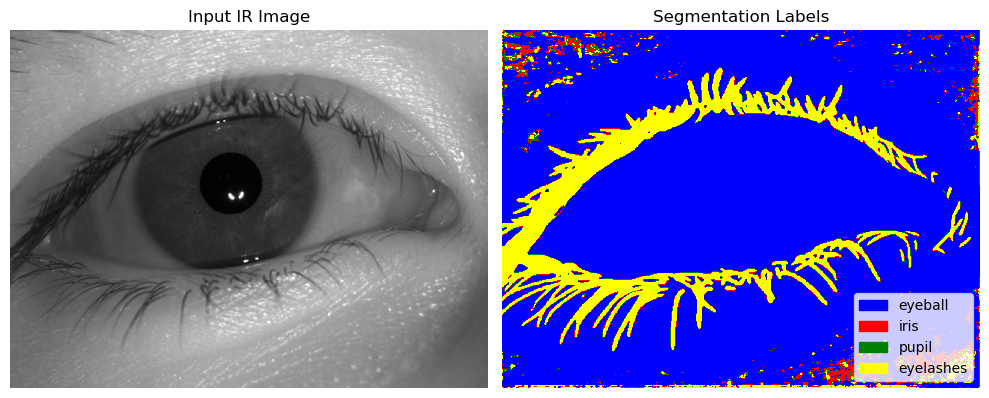

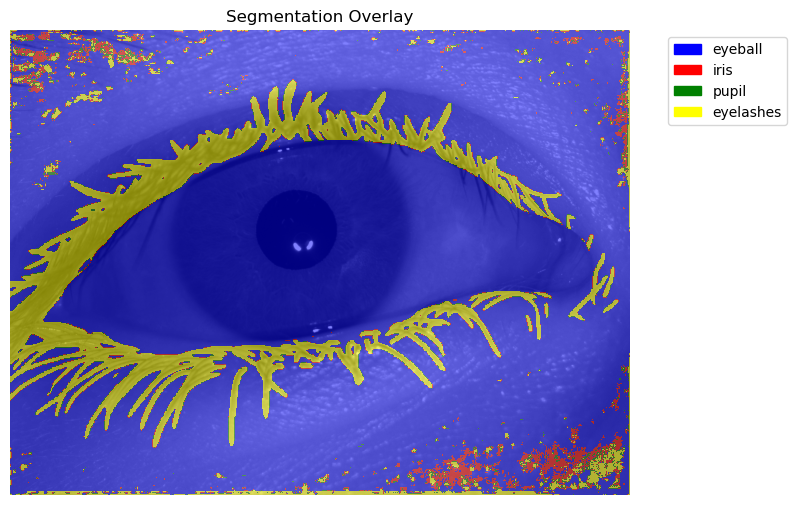

In [71]:
# ---- Imports ----
import numpy as np
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

# ---- Convert soft predictions to class labels ----
labels = np.argmax(segmentation_result.predictions, axis=2)

colors = ['blue', 'red', 'green', 'yellow']
cmap = ListedColormap(colors)

class_names = ['eyeball', 'iris', 'pupil', 'eyelashes']

fig, ax = plt.subplots(1, 2, figsize=(10,4))

# Input image
ax[0].imshow(img_pixels, cmap="gray")
ax[0].set_title("Input IR Image")
ax[0].axis("off")

# ---- Segmentation labels ----
ax[1].imshow(labels, cmap=cmap, vmin=0, vmax=3)
ax[1].set_title("Segmentation Labels")
ax[1].axis("off")

# legend patches
patches = [mpatches.Patch(color=colors[i], label=class_names[i]) 
           for i in range(len(class_names))]

# attach legend to the second subplot
ax[1].legend(handles=patches, loc="lower right")

plt.tight_layout()
plt.show()

# Overlay plot
plt.figure(figsize=(8, 8))
plt.imshow(img_pixels, cmap="gray")          # base IR image
plt.imshow(labels, cmap=cmap, alpha=0.5, vmin=0, vmax=3)  # segmentation overlay

plt.axis("off")
plt.title("Segmentation Overlay")

# Create legend handles
patches = [mpatches.Patch(color=colors[i], label=class_names[i]) for i in range(len(class_names))]
plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

### What to look for

The `MultilabelSegmentation` model often produces a soft probability map that doesn’t fully separate all classes. Some classes (like iris or pupil) may not “light up” strongly enough in the soft map, especially if the model is conservative. In this case, only eyeball vs. eyelashes were clearly separated. The iris and pupil regions probably had low probabilities, so visually they look merged with the eyeball.

| What you see | What it means|
|---|---|
|Large blue region throughout the image |Segmentation lumped classes together; some classes didn't "light up" enough to be separated. |
|Misclassified red regions|Iris regions weren't calculated correctly; probabilities weren't enough.|
|Missing green regions|Pupil regions weren't calculated correctly; probabilities weren't enough.|
|Yellow regions|Model does a generally good job classifying noise.|

---
<div style='background-color:honeydew; font-size: 24px;'>
    <center><strong>MultilabelSegmentationBinarization Node</strong></center>
</div>

---

Example from pipeline.yaml:

<code> - <font color='green'>name: segmentation_binarization</font>
    algorithm:    
      class_name: <font color='blue'>iris.MultilabelSegmentationBinarization</font>
      params: {}</code>      
<code>   inputs:
      - name: segmentation_map
        source_node: segmentation
    callbacks:</code>

**What it does**

While `MultilabelSegmentation` produces a soft probability map where all classes might not be separated, `MultilabelSegmentationBinarization` takes the soft map and applies thresholding per class. Even weakly predicted regions will have good separation, and the result is a binary mask for each class: 

Eyeball, Pupil, Iris Eyelashes.

The soft probabilites from `MultilabelSegmentation` are converted into 0's or 1's based on their probabilites.

**Key parameters**


| Parameter | Input Type | Default Value | What it controls |
|---|---|---| --- |
| eyeball_threshold | float | 0.5 | Eyeball class threshold.
| iris_threshold | float | 0.5 | Iris class threshold. |
| pupil_threshold | float | 0.5 | Pupil class threshold. |
| eyelashes_threshold | float | 0.5 | Eyelash/noise class threshold. |
| callbacks | List[Callback] | [ ] | List of algorithm callbacks. |

**Code \& Visualization Cells**

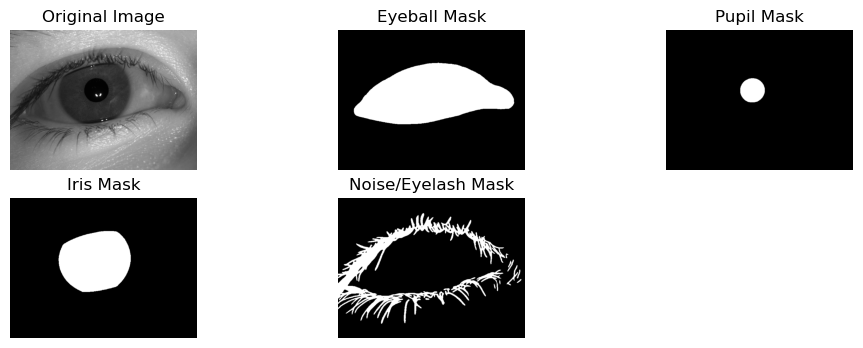

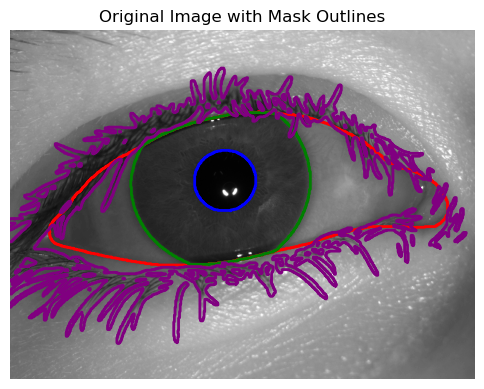

In [111]:
# ---- Imports ----
from iris import MultilabelSegmentationBinarization
from skimage import measure

# ---- MultilabelSegmentation Binarization Model ----
binarizer = MultilabelSegmentationBinarization()
geometry_mask, noise_mask = binarizer.run(segmentation_result)

# Plotting again to show masks for now each component separated correctly.
plt.figure(figsize=(12,4))

plt.subplot(2,3,1)
plt.imshow(img_pixels, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(geometry_mask.eyeball_mask, cmap="gray")
plt.title("Eyeball Mask")
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(geometry_mask.pupil_mask, cmap="gray")
plt.title("Pupil Mask")
plt.axis("off")

plt.subplot(2,3,4)
plt.imshow(geometry_mask.iris_mask, cmap="gray")
plt.title("Iris Mask")
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(noise_mask.mask, cmap="gray")
plt.title("Noise/Eyelash Mask")
plt.axis("off")

plt.show()


# ---- Overlaying binarization masks on the orignal image ----

plt.figure(figsize=(6,6))

# show original image
plt.imshow(img_pixels, cmap="gray")

# function to draw mask outlines
def plot_mask_outline(mask, color):
    contours = measure.find_contours(mask, level=0.5)  # find edges
    for contour in contours:
        plt.plot(contour[:, 1], contour[:, 0], color=color, linewidth=2)

# overlay outlines with colors
plot_mask_outline(geometry_mask.eyeball_mask, color='red')
plot_mask_outline(geometry_mask.pupil_mask, color='blue')
plot_mask_outline(geometry_mask.iris_mask, color='green')
plot_mask_outline(noise_mask.mask, color='purple')

plt.title("Original Image with Mask Outlines")
plt.axis("off")
plt.show()

### What to look for

The `MultilabelSegmentationBinarization` model will convert the probabilities into two different masks:

- *Geometry*:   parts of the eye, that will be helpful in further along iris recognition (iris, pupil, eyeball).
- *Noise*:   parts of the image not helpful in identifying the eye (eyelashes).

| What you see | What it means|
|---|---|
|Much clearer separatiin of classes, and each class is visible. |Binarization is an improved segmentation method to produce clear segments of the eye. |